In [3]:
from pathlib import Path

import bm3d
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import torch
from torch.nn.functional import mse_loss


In [137]:
images_path = Path("data/all")

normal_img_path = list(images_path.glob("Normal-*.png"))[0]
covid_img_path = list(images_path.glob("COVID-*.png"))[0]
lung_opacity_img_path = list(images_path.glob("Lung_Opacity-*.png"))[0]

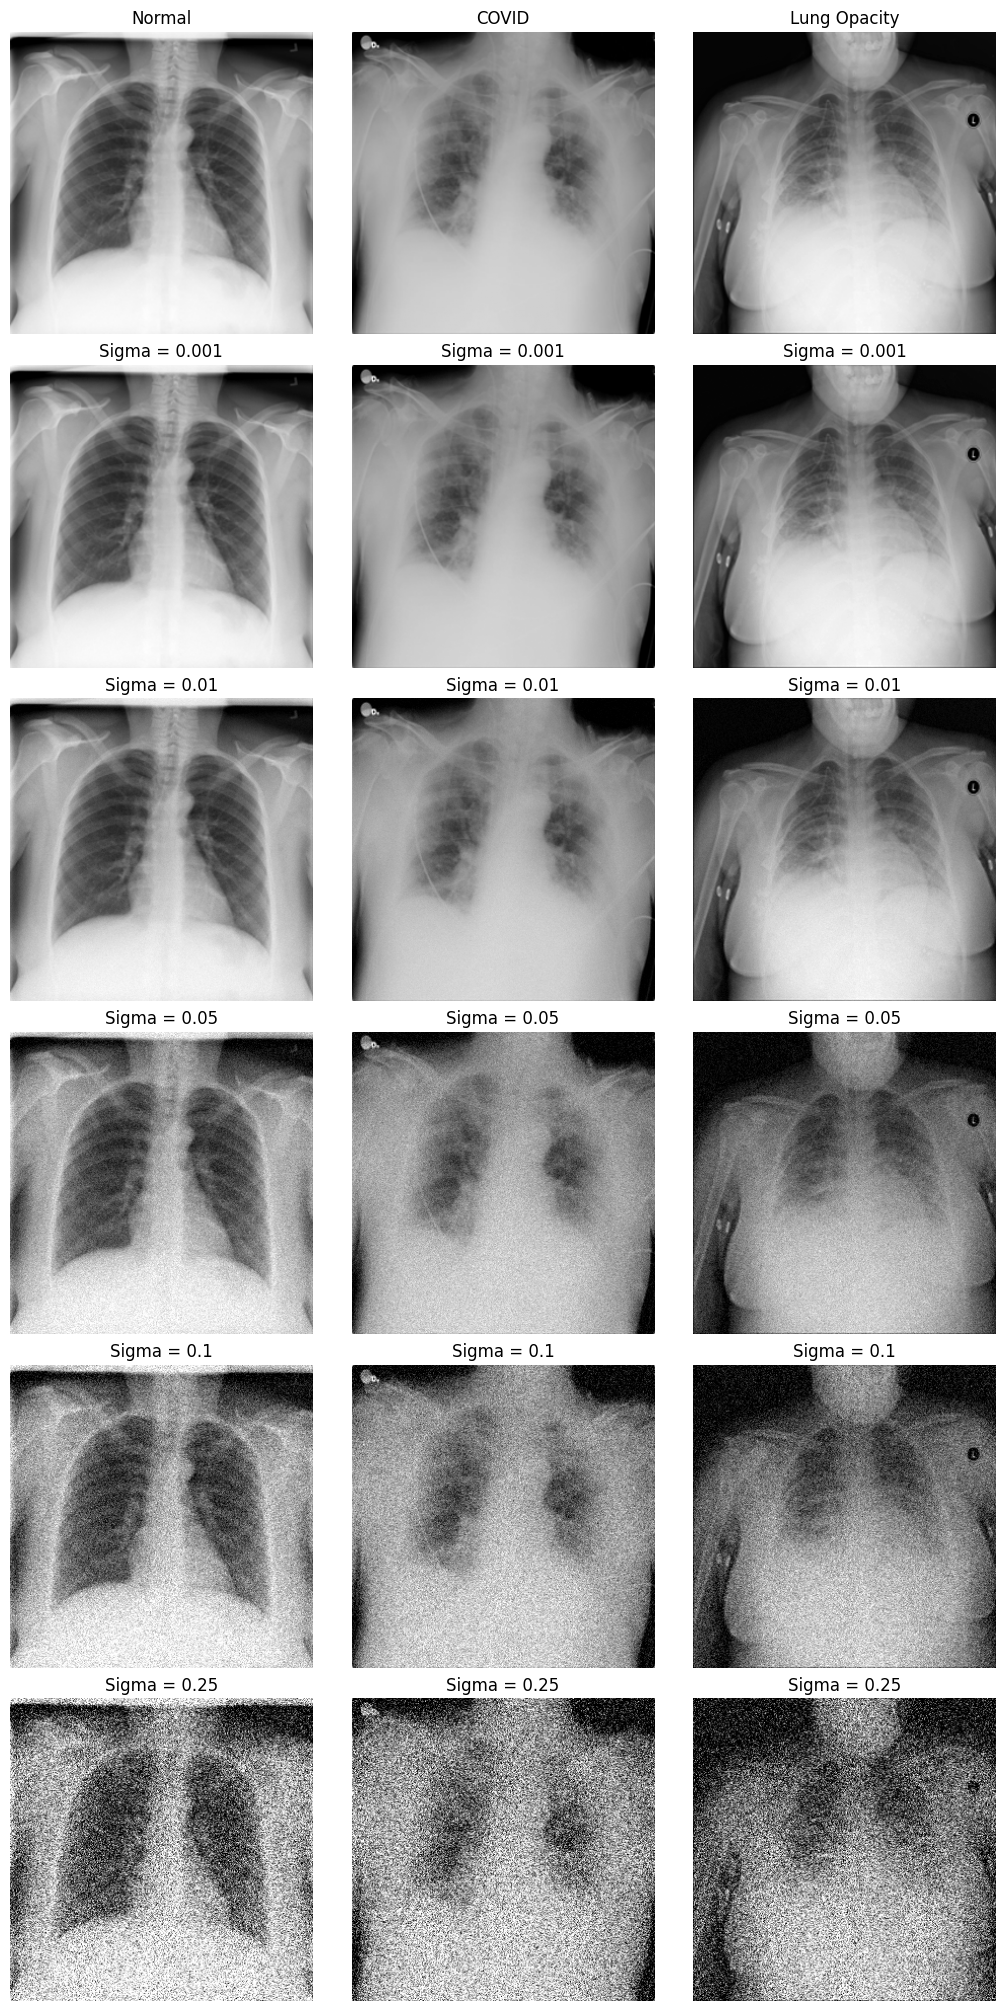

[51.18881774 39.84169391 26.16986106 20.26514146 13.09405537]
[0.99726385 0.93740216 0.43180701 0.18883726 0.04913167]


In [138]:
sigmas = [0.001, 0.01, 0.05, 0.1, 0.25]
psnr_list = []
ssim_list = []

fig, ax = plt.subplots(len(sigmas) + 1, 3, figsize=(10, 20), constrained_layout=True, gridspec_kw={'wspace': 0.1})
for i, (img_path, title) in enumerate(zip(
    [normal_img_path, covid_img_path, lung_opacity_img_path],
    ["Normal", "COVID", "Lung Opacity"]
)):
    image = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    ax[0, i].imshow(image, cmap="gray")
    ax[0, i].set_title(title)
    ax[0, i].axis("off")

    psnr_row = []
    ssim_row = []
    for j, sigma in enumerate(sigmas):
        corrupted_image = random_noise((image / 255), "gaussian", var=sigma**2)
        corrupted_image *= 255
        corrupted_image = corrupted_image.astype(np.uint8)
        ax[j+1, i].imshow(corrupted_image, cmap="gray")
        ax[j+1, i].set_title(f"Sigma = {sigma}")
        ax[j+1, i].axis("off")

        psnr_row.append(psnr(image, corrupted_image, data_range=255))
        ssim_row.append(ssim(image, corrupted_image, data_range=255))
    
    psnr_list.append(psnr_row)
    ssim_list.append(ssim_row)

plt.show()

print(np.array((psnr_list)).mean(axis=0))
print(np.array((ssim_list)).mean(axis=0))

In [4]:
img_path = "data/all/COVID-713.png"
image = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)

In [5]:
sigma = 0.1
corrupted_image = random_noise((image / 255), "gaussian", var=sigma**2)
corrupted_image *= 255
corrupted_image = corrupted_image.astype(np.uint8)

In [6]:
bm3d_image = (bm3d.bm3d(corrupted_image / 255, sigma).clip(0, 1) * 255).astype(np.uint8)

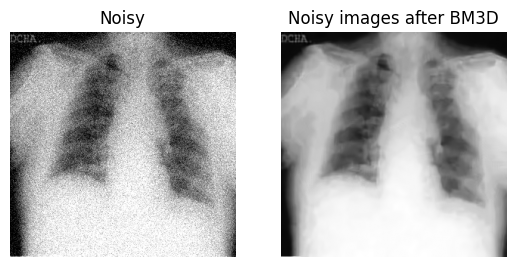

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(corrupted_image, cmap="gray")
ax1.axis("off")
ax1.set_title("Noisy")

ax2.imshow(bm3d_image, cmap="gray")
ax2.axis("off")
ax2.set_title("Noisy images after BM3D")

plt.show()


In [8]:
psnr(image, corrupted_image)

np.float64(20.592277805776643)

In [9]:
psnr(image / 255, bm3d_image / 255)

np.float64(32.75323999640783)

In [43]:
def torch_psnr(images_a, images_b):
    mse = mse_loss(images_a, images_b, reduction='none').mean(dim=(1, 2, 3))
    return 20 * torch.log10(1 / torch.sqrt(mse))

In [44]:
image_tensor = torch.Tensor((image / 255)[None, ...])
bm3d_image_tensor = torch.Tensor((bm3d_image / 255)[None, ...])

In [45]:
image_tensor.shape

torch.Size([1, 299, 299])

In [40]:
torch_psnr(image_tensor, bm3d_image_tensor)

ValueError: None is not a valid value for reduction

In [46]:
image_tensor = image_tensor.repeat(10, 1, 1).reshape(10, 1, 299, 299)
bm3d_image_tensor = bm3d_image_tensor.repeat(10, 1, 1).reshape(10, 1, 299, 299)


In [47]:
torch_psnr(image_tensor, bm3d_image_tensor)

tensor([32.7532, 32.7532, 32.7532, 32.7532, 32.7532, 32.7532, 32.7532, 32.7532,
        32.7532, 32.7532])